In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from latex_io import format_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "figure.titlesize": 18,
    }
)
plt.rcParams["figure.figsize"] = (8, 5)

In [142]:
def conf_matrix(y_test, y_pred, model):
    cm = confusion_matrix(y_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    fn = cm[1, 0]
    tp = cm[1, 1]
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * (precision * recall) / (precision + recall)
    print(f"------{model}---------")
    print(cm)
    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall (TPR): {recall*100:.2f}%")
    print(f"F1 Score: {f1*100:.2f}%")
    print("---------------")
    return accuracy, precision, recall, f1


def threshold_analysis(y_test, y_prob, model_name="Model"):
    """
    find best threshold

    Args:
        y_test (_type_): _description_
        y_prob (_type_): _description_
        model_name (str, optional): _description_. Defaults to "Model".
    """

    thresholds = np.linspace(0.01,0.9, 100)
    accuracies = []
    precisions = []
    recalls = []
    f1_scores = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        accuracies.append(accuracy_score(y_test, y_pred)) #hehe of course its a build in function in metrics
        precisions.append(precision_score(y_test, y_pred, zero_division=0))
        recalls.append(recall_score(y_test, y_pred, zero_division=0))
        f1_scores.append(f1_score(y_test, y_pred, zero_division=0))

    #fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    metrics = [
        ("Accuracy", accuracies),
        ("Precision", precisions),
        ("Recall", recalls),
        ("F1 Score", f1_scores),
    ]
    for (name, values) in metrics:
        plt.plot(thresholds, values, label = name)
        plt.grid()
        plt.ylabel("a.u")
        plt.xlabel("Threshold")
    plt.legend()
    #for ax, (name, values) in zip(axes.flatten(), metrics):
    #    axes[0,0].plot(thresholds, values, label = name)
    #    #ax.set_title(f"{model_name}: {name}")
    #    ax.set_xlabel("Threshold")
    #    ax.set_ylabel(name)
    #    ax.grid(True)
    #    ax.legend()
    plt.tight_layout()
    plt.savefig(f"pictures/thresholds_{model_name}.pdf", bbox_inches = "tight")
    plt.show()
    best_index = np.argmax(f1_scores)
    print(f"Best threshold based on F1:")
    print(f"Threshold: {thresholds[best_index]:.3f}")
    print(f"F1 Score: {f1_scores[best_index]:.3f}")
    print(f"Precision: {precisions[best_index]:.3f}")
    print(f"Recall: {recalls[best_index]:.3f}")
    print(f"Accuracy: {accuracies[best_index]:.3f}")

In [143]:
# import dataset
df = pd.read_excel("data/Assignment_Dataset_2.xlsx", sheet_name=0)
features = ["DSRI", "GMI", "AQI", "SGI", "DEPI", "SGAI", "ACCR", "LEVI"]
X = df[features].to_numpy()
Y = df["Manipulater"].map({"No": 0, "Yes": 1}).values

In [144]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=123,  # keep same samples in whole script
    stratify=Y,  # keep ratio from manipulater in X,Y
)

In [145]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [146]:
# Logistic Regression model
log_model = LogisticRegression(
    random_state=123,
    max_iter=1000,
    class_weight="balanced",
    penalty="l2",
    solver="liblinear",
)
log_model.fit(X_train_scaled, y_train)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
threshold_log = 0.5
y_pred_log = (y_prob_log >= threshold_log).astype(int)
log_res = conf_matrix(y_test, y_pred_log, "Logistic Regression")

------Logistic Regression---------
[[208  32]
 [  2   6]]
Accuracy: 86.29%
Precision: 15.79%
Recall (TPR): 75.00%
F1 Score: 26.09%
---------------


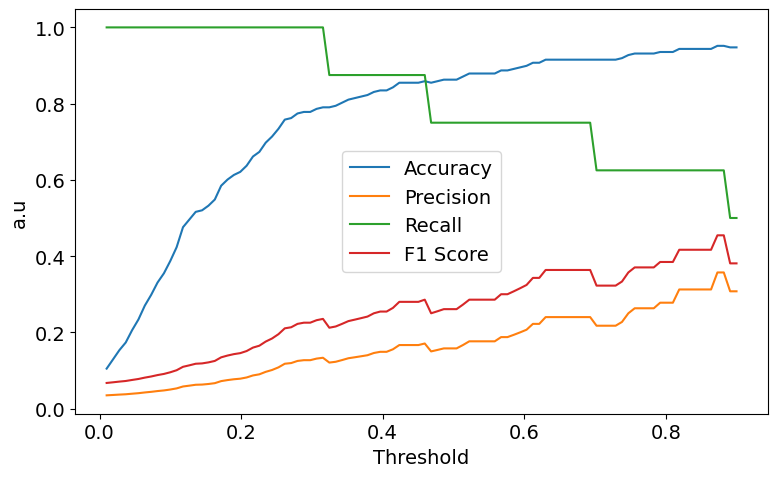

Best threshold based on F1:
Threshold: 0.873
F1 Score: 0.455
Precision: 0.357
Recall: 0.625
Accuracy: 0.952


In [147]:
threshold_analysis(y_test, y_prob_log, "Logistic Regression")

In [148]:
## Random Forest model
#param_grid = {
#    "n_estimators": [200, 500],
#    "max_depth": [5, 8, 12, None],
#    "min_samples_leaf": [1, 3, 5],
#    "min_samples_split": [2, 5, 10],
#}
#rf = RandomForestClassifier(random_state=123, class_weight="balanced_subsample")
#grid = GridSearchCV(rf, param_grid, scoring="f1", cv=5, n_jobs=-1)
#grid.fit(X_train, y_train)
#print(grid.best_params_)
## result
## {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 500}

In [149]:
# Contiue Random Forest
rf_model = RandomForestClassifier(
    class_weight="balanced",
    random_state=123,
    max_depth=5,
    min_samples_leaf=5,
    min_samples_split=2,
    n_estimators=500,
)
rf_model.fit(X_train, y_train)  # not scaled
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
threshold_rf = 0.5
y_pred_rf = (y_prob_rf >= threshold_rf).astype(int)
#for t_rf in [0.5, 0.4, 0.3, 0.2, 0.1]:
#    y_pred_rf = (y_prob_rf >= t_rf).astype(int)
#    print(f"threshold: {t_rf}")
#    rf_res = conf_matrix(y_test, y_pred_rf, "Random Forest")
#    accuracy, precision, recall, f1 = rf_res
#    print("\n")
rf_res = conf_matrix(y_test, y_pred_rf, "Random Forest")

------Random Forest---------
[[235   5]
 [  7   1]]
Accuracy: 95.16%
Precision: 16.67%
Recall (TPR): 12.50%
F1 Score: 14.29%
---------------


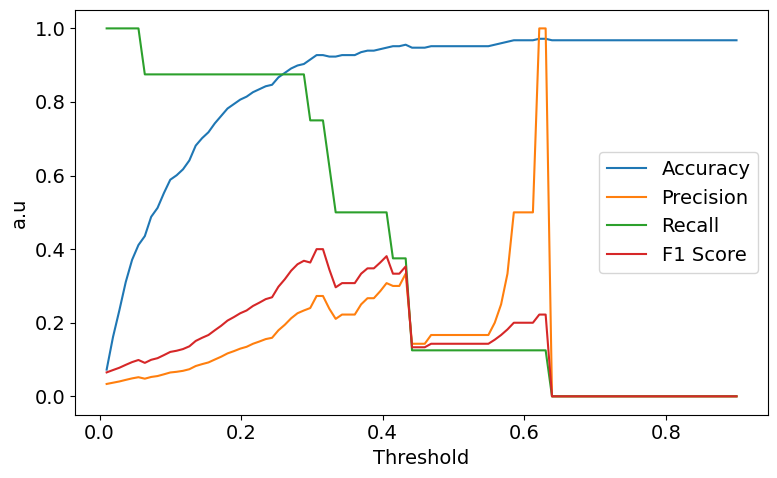

Best threshold based on F1:
Threshold: 0.307
F1 Score: 0.400
Precision: 0.273
Recall: 0.750
Accuracy: 0.927


In [150]:
threshold_analysis(
    y_test,
    y_prob_rf,
    "Random Forest"
)

Importance Random forest
ACCR    0.187683
SGAI    0.163988
SGI     0.163849
DSRI    0.157494
LEVI    0.113291
GMI     0.091170
AQI     0.065437
DEPI    0.057088
dtype: float64


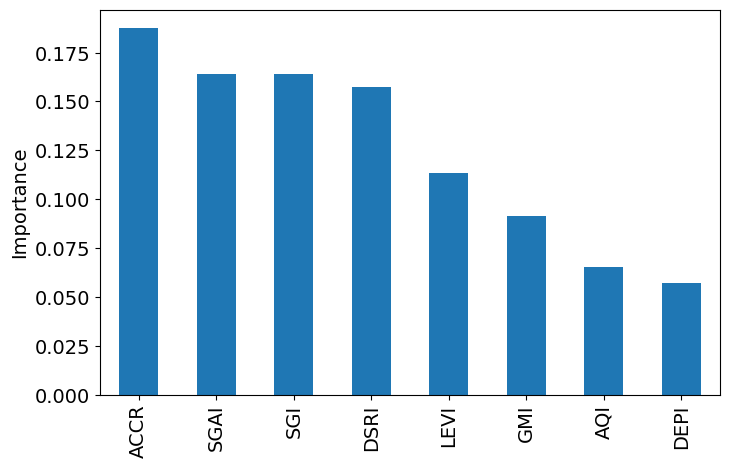

In [151]:
# RF feature importance
# additional random forest analysis
importance = pd.Series(
    rf_model.feature_importances_, index=features
).sort_values(ascending=False)
print("Importance Random forest")
print(importance)
importance.plot(kind="bar")
plt.ylabel("Importance")
plt.savefig(f"pictures/rf_feature_importance2.pdf", bbox_inches="tight")
plt.show()

In [152]:
# Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=123,
    class_weight="balanced",
    max_depth=5,
    min_samples_leaf=5,
    min_samples_split=2,
)
dt_model.fit(X_train, y_train)

y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
threshold_dt = 0.5
y_pred_dt = (y_prob_dt >= threshold_dt).astype(int)

dt_res = conf_matrix(y_test, y_pred_dt, "Decision Tree")

------Decision Tree---------
[[209  31]
 [  1   7]]
Accuracy: 87.10%
Precision: 18.42%
Recall (TPR): 87.50%
F1 Score: 30.43%
---------------


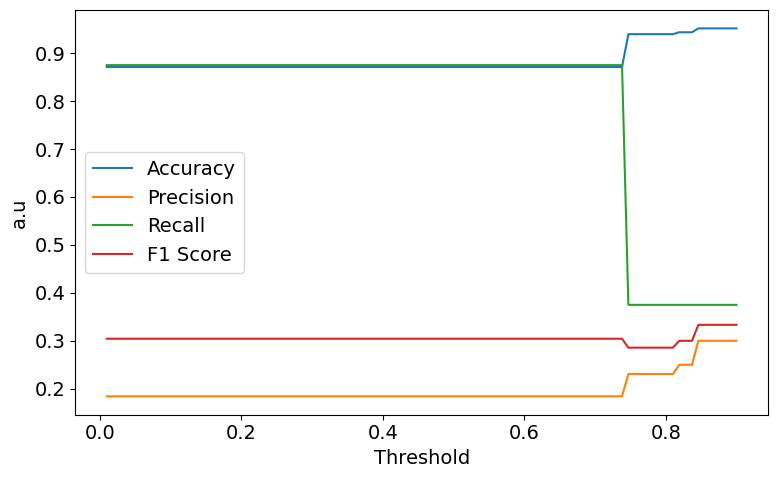

Best threshold based on F1:
Threshold: 0.846
F1 Score: 0.333
Precision: 0.300
Recall: 0.375
Accuracy: 0.952


In [153]:
threshold_analysis(y_test, y_prob_dt, "Decision Tree")

In [154]:
plot_tree(
    dt_model,
    feature_names=features,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True
)
plt.savefig(
    "pictures/decision_tree.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


In [155]:
#xgb_model = XGBClassifier(
#    random_state=123,
#    objective="binary:logistic",
#    eval_metric="logloss",
#    scale_pos_weight=1200 / 39,
#)
#
#param_grid = {
#    "max_depth": [3, 4, 5],
#    "learning_rate": [0.01, 0.05, 0.1],
#    "n_estimators": [200, 400, 600],
#    "min_child_weight": [1, 3, 5],
#    "subsample": [0.8, 1.0],
#    "colsample_bytree": [0.8, 1.0],
#}
#
#grid = GridSearchCV(
#    estimator=xgb_model, param_grid=param_grid, scoring="f1", cv=5, n_jobs=-1
#)
#
## Training!
#grid.fit(X_train, y_train)
#
#print("Beste Parameter:")
#print(grid.best_params_)
#
#print("Bester F1:")
#print(grid.best_score_)
## result
## Beste Parameter:
## {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 600, 'subsample': 0.8}
## Bester F1:
## 0.4488311688311688

In [ ]:
# XGBoost model
params = {
    "colsample_bytree": 0.8,
    "learning_rate": 0.1,
    "max_depth": 4,
    "min_child_weight": 5,
    "n_estimators": 600,
    "subsample": 0.8,
}
xgb_model = XGBClassifier(
    random_state=123,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=1200 / 39,
    **params,
)

xgb_model.fit(X_train, y_train)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
threshold_xgb = 0.5
y_pred_xgb = (y_prob_xgb >= threshold_xgb).astype(int)
xgb_res = conf_matrix(y_test, y_pred_xgb, "XGBoost")
# for t_xgb in [0.5, 0.4, 0.3, 0.2, 0.1]:
#    y_pred_xgb = (y_prob_xgb >= t_xgb).astype(int)
#    print(f"Threshold: {t_xgb}")
#    res = conf_matrix(y_test, y_pred_xgb, "XGBoost")
#    print("\n")

------XGBoost---------
[[237   3]
 [  5   3]]
Accuracy: 96.77%
Precision: 50.00%
Recall (TPR): 37.50%
F1 Score: 42.86%
---------------


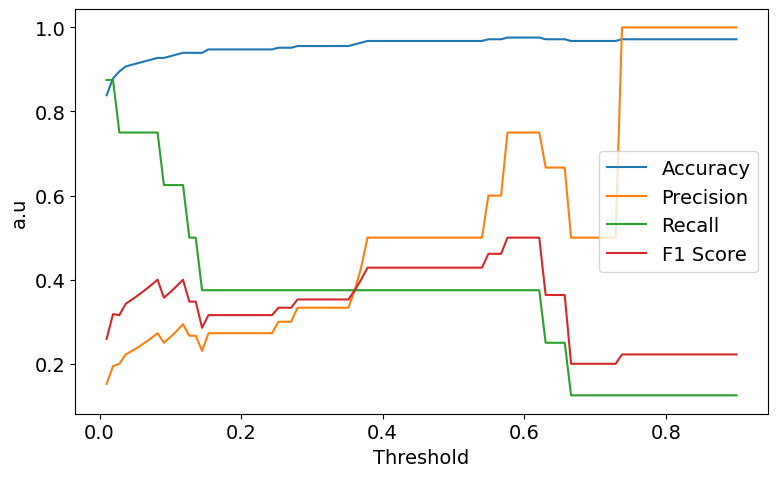

Best threshold based on F1:
Threshold: 0.576
F1 Score: 0.500
Precision: 0.750
Recall: 0.375
Accuracy: 0.976


In [157]:
threshold_analysis(y_test, y_prob_xgb, "XGBoost")

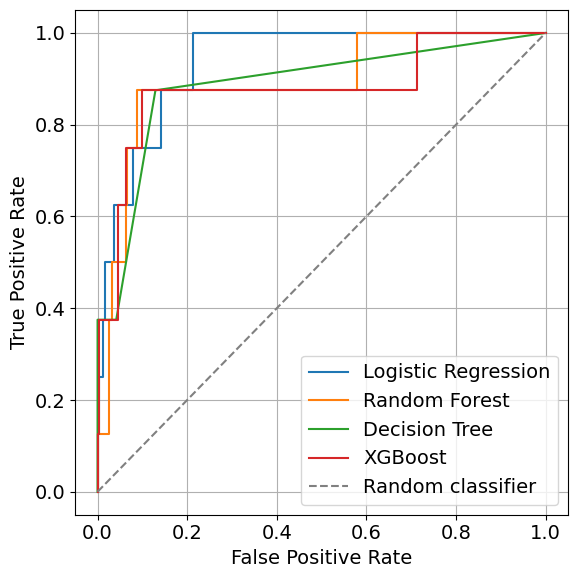

------Logistic Regression---------
AUC: 0.94
Gini: 0.87
---------------
------Decision Tree---------
AUC: 0.89
Gini: 0.77
---------------
------Random Forest---------
AUC: 0.89
Gini: 0.78
---------------
------XGBoost---------
AUC: 0.88
Gini: 0.76
---------------


In [158]:
# roc curves
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.figure(figsize=(6, 6))
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_dt, tpr_dt, label = "Decision Tree")
plt.plot(fpr_xgb, tpr_xgb, label = "XGBoost")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(f"pictures/roc_2.pdf", bbox_inches="tight")
plt.show()

def benchmark(fpr, tpr, model):
    print(f"------{model}---------")
    auc_val = auc(fpr, tpr)
    print(f"AUC: {auc_val:.2f}")
    gini = 2 * auc_val - 1
    print(f"Gini: {gini:.2f}")
    print("---------------")

benchmark(fpr_log, tpr_log, "Logistic Regression")
benchmark(fpr_dt, tpr_dt, "Decision Tree")
benchmark(fpr_rf, tpr_rf, "Random Forest")
benchmark(fpr_xgb, tpr_xgb, "XGBoost")
